In [ ]:
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from langchain_chroma import Chroma
from langchain_ollama import ChatOllama

In [2]:
retriver = Chroma(persist_directory="db\chroma")

<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\Sangram Mishra\AppData\Local\Temp\ipykernel_4360\857041030.py:1: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  retriver = Chroma(persist_directory="db\chroma")


In [35]:
retrive =  retriver.as_retriever(search_kwargs = {
    "k" : 8

})

In [11]:
retrive.invoke("what are attentions")

[Document(id='dae9e9ff-7b7f-476b-a75b-6a70e26700dc', metadata={'firstpage': '5998', 'title': 'Attention is All you Need', 'book': 'Advances in Neural Information Processing Systems 30', 'subject': 'Neural Information Processing Systems http://nips.cc/', 'moddate': '2018-02-12T21:22:10-08:00', 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less timeto train. Our single model with 165 million parameters, achieves 27.5 BLEU onEnglish-to-German translation, improving over the existing

In [12]:
from langchain_core.documents import Document
from typing import NotRequired

In [ ]:
class rag_state(TypedDict):
    qusestion : str
    context: NotRequired[list[Document]]
    answer:  NotRequired[str]
    retry : int

In [48]:
def retriv(state:rag_state):
    return {
        "context":retrive.invoke(state["qusestion"])
    }

In [58]:
class st_it(BaseModel):
    output: bool = Field(description="return relevancy of context")

In [107]:
llm = ChatOllama(model = "qwen3:8b")

In [108]:
llm_struc_ot = llm.with_structured_output(st_it)

In [109]:
res = llm_struc_ot.invoke('''qustion is "can car fly", context is "aeroplane can fly because it leg"''')

In [110]:
if res:
    print(True)

True


In [111]:
res.output

False

In [112]:
def context_evaluator(state:rag_state):
    context = "\n\n".join([context.page_content
                         for context in state["context"]])

    message = f"""you are
    a evaluator assistant your work is to evaluate whether 
    the given qustion the retrived context is valid or not
    so the qustion is here {state['qusestion']} and 
    retrived context is here {context}"""

    response = llm_struc_ot.invoke(message)

    if response.output:
        print(response)
        return "generate_content"
    print("retrying the generatd context i not relevant")
    return "retrive_again"


In [75]:
gen_llm = ChatOllama(model="qwen3:8b")

In [79]:
def generate(state:rag_state):

    context = "\n\n".join([doc.page_content for doc in state["context"]])
    messages = [{"role":"system","content":"""you are an helpfull assistant generate answer with given context and qustion "
        if you dont know the answer then say simply i dont know the answer dont halucinate"""},
        {"role":"user","content": f"please provied answer my qustion is {state["qusestion"]} and context is {context}"
    }]
    answer = gen_llm.invoke(messages)
    return {
        "answer":answer.content }

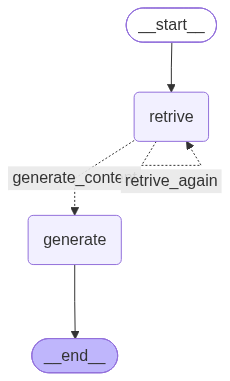

In [113]:
graph = StateGraph(rag_state)
graph.add_node("retrive",retriv)
graph.add_node("generate",generate)

graph.add_edge(START,"retrive")
graph.add_conditional_edges("retrive",context_evaluator,{
    "generate_content":"generate",
    "retrive_again":"retrive"
})
graph.add_edge("generate",END)
app = graph.compile()
app

In [114]:
result = app.invoke({
    "qusestion": "explain rag is 700 words"
})

retrying the generatd context i not relevant
retrying the generatd context i not relevant
retrying the generatd context i not relevant


KeyboardInterrupt: 

In [106]:
print(result['answer'])

I don't know the answer. The provided context does not mention or explain Retrieval-Augmented Generation (RAG). The references and text focus on topics like neural machine translation, subword units, self-attention mechanisms, and Transformer architecture, but none relate to RAG.
